# Interpretabilidad SHAP de la Reference CNN

Este notebook explica el checkpoint seleccionado de la **Reference CNN** sin volver a entrenarlo. Utiliza la partición congelada por `source_id` y genera:

- explicaciones locales de predicciones correctas y errores;
- regiones Raman influyentes agrupadas en ventanas de aproximadamente 10–20 cm⁻¹;
- una figura resumen con cuatro casos representativos;
- una prueba de oclusión frente a regiones aleatorias;
- una comprobación opcional de estabilidad ante dos conjuntos de referencia.

Los valores SHAP indican qué regiones influyen en la salida del modelo respecto al conjunto de referencia. **No demuestran causalidad química** y deben contrastarse con conocimiento mineralógico.

## 1. Requisitos y archivos esperados

El notebook ganador debe haberse ejecutado hasta su sección de exportación. Se esperan:

- `raman_all_7_zips_mixed_fixed_split_5_seeds/results/PRODUCTION_BUNDLE.zip`
- `raman_all_7_zips_mixed_fixed_split_5_seeds/results/FROZEN_SPLIT_MANIFEST.csv`
- los archivos extraídos por el notebook ganador o, como alternativa, los siete ZIP originales.

Si los archivos están en otra ubicación, modifica las rutas de la siguiente celda. El paquete de producción contiene el modelo elegido exclusivamente mediante validación, las etiquetas y la rejilla Raman.

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd()
WINNER_WORK_DIR = PROJECT_ROOT / "raman_all_7_zips_mixed_fixed_split_5_seeds"
RESULTS_DIR = WINNER_WORK_DIR / "results"

BUNDLE_PATH = Path(os.environ.get(
    "REFERENCE_CNN_BUNDLE",
    RESULTS_DIR / "PRODUCTION_BUNDLE.zip",
)).expanduser()
SPLIT_MANIFEST_PATH = Path(os.environ.get(
    "REFERENCE_CNN_SPLIT_MANIFEST",
    RESULTS_DIR / "FROZEN_SPLIT_MANIFEST.csv",
)).expanduser()
EXTRACTED_SPECTRA_ROOT = Path(os.environ.get(
    "REFERENCE_CNN_EXTRACTED_ROOT",
    WINNER_WORK_DIR / "extracted",
)).expanduser()

OUTPUT_DIR = PROJECT_ROOT / "reference_cnn_shap_results"
ARTIFACT_DIR = OUTPUT_DIR / "production_artifacts"
CASE_FIGURE_DIR = OUTPUT_DIR / "case_figures"

SEED = 42
BACKGROUND_PER_CLASS = 1       # Una señal real de entrenamiento por clase.
N_HIGH_CONFIDENCE_CORRECT = 4
N_LOW_CONFIDENCE_CORRECT = 4
N_TARGETED_ERRORS = 4
N_GENERAL_ERRORS = 4
SHAP_NSAMPLES = 200
WINDOW_POINTS = 8              # 8 × ~2,07 cm⁻¹ = ~16,6 cm⁻¹.
TOP_WINDOWS_PER_CASE = 5
OCCLUSION_WINDOWS = 3
RUN_BACKGROUND_STABILITY = True
STABILITY_CASES = 4

TARGET_CONFUSIONS = [
    ("Polylithionite", "Trilithionite"),
    ("Actinolite", "Pargasite"),
    ("Diopside", "Augite"),
    ("Axinite-(Mn)", "Axinite-(Fe)"),
    ("Jarosite", "Natrojarosite"),
    ("Fluor-uvite", "Dravite"),
]

for directory in (OUTPUT_DIR, ARTIFACT_DIR, CASE_FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Paquete del modelo:", BUNDLE_PATH.resolve())
print("Partición congelada:", SPLIT_MANIFEST_PATH.resolve())
print("Resultados SHAP:", OUTPUT_DIR.resolve())

Paquete del modelo: /Users/nico/anaconda_projects/TFM - FINAL/raman_all_7_zips_mixed_fixed_split_5_seeds/results/PRODUCTION_BUNDLE.zip
Partición congelada: /Users/nico/anaconda_projects/TFM - FINAL/raman_all_7_zips_mixed_fixed_split_5_seeds/results/FROZEN_SPLIT_MANIFEST.csv
Resultados SHAP: /Users/nico/anaconda_projects/TFM - FINAL/reference_cnn_shap_results


## 2. Dependencias

Se utiliza `GradientExplainer`, basado en gradientes esperados y compatible con modelos diferenciables de TensorFlow. Si SHAP no está instalado, la celda lo instalará en el entorno activo. Puede ser necesario reiniciar el kernel después de una instalación nueva.

In [2]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("shap") is None:
    print("SHAP no está instalado. Iniciando instalación...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])

import hashlib
import json
import zipfile
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import shap
import tensorflow as tf

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print("TensorFlow:", tf.__version__)
print("SHAP:", shap.__version__)

TensorFlow: 2.21.0
SHAP: 0.51.0


## 3. Carga y verificación del paquete de producción

Se verifican los hashes del paquete antes de cargar el modelo. El checkpoint permanece congelado y se usa con `training=False`; no se actualizan pesos.

In [3]:
def find_unique_file(path, filename):
    path = Path(path)
    if path.is_file():
        return path
    search_roots = [PROJECT_ROOT, PROJECT_ROOT / "upload", Path("/content")]
    matches = []
    for root in search_roots:
        if root.exists():
            matches.extend(root.rglob(filename))
    matches = sorted({item.resolve() for item in matches if item.is_file()})
    if len(matches) == 1:
        return matches[0]
    if not matches:
        raise FileNotFoundError(
            f"No se encontró {filename}. Ejecuta la exportación del notebook ganador "
            "o corrige la ruta en la celda de configuración."
        )
    raise RuntimeError(f"Se encontraron varias copias de {filename}: {matches}. Especifica la ruta exacta.")

BUNDLE_PATH = find_unique_file(BUNDLE_PATH, "PRODUCTION_BUNDLE.zip")
SPLIT_MANIFEST_PATH = find_unique_file(SPLIT_MANIFEST_PATH, "FROZEN_SPLIT_MANIFEST.csv")

with zipfile.ZipFile(BUNDLE_PATH, "r") as archive:
    archive.extractall(ARTIFACT_DIR)

required = {
    "production_model.keras", "class_labels.json", "raman_grid.npy",
    "preprocessing_contract.json", "production_selection.json", "artifact_manifest.json",
}
missing = sorted(name for name in required if not (ARTIFACT_DIR / name).is_file())
if missing:
    raise RuntimeError(f"El paquete de producción está incompleto. Faltan: {missing}")

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

artifact_manifest = json.loads((ARTIFACT_DIR / "artifact_manifest.json").read_text(encoding="utf-8"))
for item in artifact_manifest["files"]:
    artifact_path = ARTIFACT_DIR / item["name"]
    if not artifact_path.is_file():
        raise RuntimeError(f"Falta el artefacto declarado: {item['name']}")
    if artifact_path.stat().st_size != int(item["size_bytes"]):
        raise RuntimeError(f"Tamaño inesperado en {item['name']}")
    if sha256_file(artifact_path) != item["sha256"]:
        raise RuntimeError(f"Hash SHA-256 inválido en {item['name']}")

labels = json.loads((ARTIFACT_DIR / "class_labels.json").read_text(encoding="utf-8"))
raman_grid = np.load(ARTIFACT_DIR / "raman_grid.npy").astype(np.float32)
selection = json.loads((ARTIFACT_DIR / "production_selection.json").read_text(encoding="utf-8"))
model = tf.keras.models.load_model(ARTIFACT_DIR / "production_model.keras", compile=False)
model.trainable = False

if tuple(model.input_shape[1:]) != (raman_grid.size, 1):
    raise RuntimeError(f"Forma de entrada incompatible: {model.input_shape}")
if int(model.output_shape[-1]) != len(labels):
    raise RuntimeError("Las salidas del modelo no coinciden con las etiquetas.")

split_manifest = pd.read_csv(SPLIT_MANIFEST_PATH)
required_columns = {"filename", "dataset_subset", "label", "class_index", "partition"}
missing_columns = required_columns - set(split_manifest.columns)
if missing_columns:
    raise RuntimeError(f"Faltan columnas en el manifiesto: {sorted(missing_columns)}")

print("✓ Paquete íntegro")
print("✓ Modelo:", model.input_shape, "→", model.output_shape)
print("✓ Semilla seleccionada por validación:", selection.get("selected_seed"))
print("✓ Registros del manifiesto:", len(split_manifest))

✓ Paquete íntegro
✓ Modelo: (None, 512, 1) → (None, 255)
✓ Semilla seleccionada por validación: 123
✓ Registros del manifiesto: 11912


## 4. Recuperación y preprocesamiento de los espectros

Se reutilizan exactamente la rejilla y la normalización del modelo ganador. El notebook busca primero los archivos extraídos y, si no están disponibles, lee directamente los siete ZIP originales.

In [4]:
import re

NUMBER = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[Ee][-+]?\d+)?")

def parse_spectrum_text(text):
    pairs = []
    for line in text.splitlines():
        if line.lstrip().startswith("##") or not line.strip():
            continue
        values = NUMBER.findall(line)
        if len(values) >= 2:
            try:
                pairs.append((float(values[0]), float(values[1])))
            except ValueError:
                pass
    if len(pairs) < 10:
        raise ValueError("El espectro contiene menos de diez pares numéricos.")
    frame = pd.DataFrame(pairs, columns=["shift", "intensity"])
    frame = frame.replace([np.inf, -np.inf], np.nan).dropna()
    frame = frame.groupby("shift", as_index=False)["intensity"].mean().sort_values("shift")
    if len(frame) < 10:
        raise ValueError("El espectro no contiene suficientes posiciones Raman válidas.")
    return frame["shift"].to_numpy(), frame["intensity"].to_numpy()

def preprocess_raw_spectrum(shift, intensity):
    shift = np.asarray(shift, dtype=np.float64)
    intensity = np.asarray(intensity, dtype=np.float64)
    grid64 = np.asarray(raman_grid, dtype=np.float64)

    # La rejilla del bundle se serializa como float32. En sus extremos puede
    # diferir unas diezmilésimas del límite usado originalmente para filtrar
    # los espectros, aunque ambos representen el mismo valor físico.
    coverage_tolerance = max(
        1e-3,
        10.0
        * np.finfo(np.float32).eps
        * max(1.0, abs(float(grid64[0])), abs(float(grid64[-1]))),
    )
    if (
        shift[0] > grid64[0] + coverage_tolerance
        or shift[-1] < grid64[-1] - coverage_tolerance
    ):
        raise ValueError(
            "El espectro no cubre por completo la rejilla serializada: "
            f"espectro=[{shift[0]:.6f}, {shift[-1]:.6f}], "
            f"rejilla=[{grid64[0]:.6f}, {grid64[-1]:.6f}], "
            f"tolerancia={coverage_tolerance:.6g}."
        )

    # Recorta únicamente el posible exceso numérico de los extremos; no
    # admite extrapolar un intervalo Raman realmente ausente.
    interpolation_grid = np.clip(grid64, shift[0], shift[-1])
    signal = np.interp(interpolation_grid, shift, intensity)
    scale = float(np.max(np.abs(signal)))
    if not np.isfinite(scale) or scale <= 1e-12:
        raise ValueError("No se puede normalizar el espectro.")
    return (signal / scale).astype(np.float32)[:, None]

# Índice de archivos extraídos.
extracted_index = defaultdict(list)
candidate_extracted_roots = [
    EXTRACTED_SPECTRA_ROOT,
    BUNDLE_PATH.parent.parent / "extracted",
    PROJECT_ROOT / "raman_all_7_zips_mixed_fixed_split_5_seeds" / "extracted",
]
for root in candidate_extracted_roots:
    if root.exists():
        for path in root.rglob("*.txt"):
            for domain in split_manifest["dataset_subset"].unique():
                if domain in path.parts or domain in str(path):
                    extracted_index[(str(domain), path.name)].append(path)
                    break

# Índice de miembros dentro de los ZIP originales.
zip_handles = {}
zip_members = {}
zip_search_roots = [PROJECT_ROOT, PROJECT_ROOT / "upload", Path("/content")]
for domain in sorted(split_manifest["dataset_subset"].unique()):
    archive_name = f"{domain}.zip"
    archive_matches = []
    for root in zip_search_roots:
        if root.exists():
            archive_matches.extend(root.rglob(archive_name))
    archive_matches = sorted({p.resolve() for p in archive_matches if p.is_file()})
    if archive_matches:
        handle = zipfile.ZipFile(archive_matches[0], "r")
        zip_handles[domain] = handle
        member_map = defaultdict(list)
        for member in handle.namelist():
            if not member.endswith("/"):
                member_map[Path(member).name].append(member)
        zip_members[domain] = member_map

def read_manifest_spectrum(row):
    domain, filename = str(row.dataset_subset), str(row.filename)
    stored_path = Path(str(getattr(row, "filepath", "")))
    if stored_path.is_file():
        text = stored_path.read_text(encoding="utf-8", errors="replace")
    elif (PROJECT_ROOT / stored_path).is_file():
        text = (PROJECT_ROOT / stored_path).read_text(encoding="utf-8", errors="replace")
    elif extracted_index.get((domain, filename)):
        paths = extracted_index[(domain, filename)]
        if len(paths) != 1:
            raise RuntimeError(f"Ruta ambigua para {domain}/{filename}: {paths}")
        text = paths[0].read_text(encoding="utf-8", errors="replace")
    elif domain in zip_handles and zip_members[domain].get(filename):
        members = zip_members[domain][filename]
        if len(members) != 1:
            raise RuntimeError(f"Miembro ZIP ambiguo para {domain}/{filename}: {members}")
        text = zip_handles[domain].read(members[0]).decode("utf-8", errors="replace")
    else:
        raise FileNotFoundError(f"No se encontró el espectro {domain}/{filename}")
    shift, intensity = parse_spectrum_text(text)
    try:
        return preprocess_raw_spectrum(shift, intensity)
    except ValueError as exc:
        raise ValueError(f"Error en {domain}/{filename}: {exc}") from exc

def load_rows(frame, description):
    signals = []
    for position, row in enumerate(frame.itertuples(index=False), start=1):
        signals.append(read_manifest_spectrum(row))
        if position % 500 == 0:
            print(f"{description}: {position}/{len(frame)}")
    result = np.asarray(signals, dtype=np.float32)
    if result.shape[1:] != (raman_grid.size, 1):
        raise AssertionError(f"Forma inesperada para {description}: {result.shape}")
    return result

print("Archivos extraídos indexados:", sum(len(v) for v in extracted_index.values()))
print("ZIP disponibles:", sorted(zip_handles))

Archivos extraídos indexados: 84345
ZIP disponibles: ['excellent_oriented', 'excellent_unoriented', 'fair_oriented', 'fair_unoriented', 'poor_unoriented', 'unrated_oriented', 'unrated_unoriented']


## 5. Conjunto de referencia y conjunto de prueba

El fondo SHAP contiene una observación real de entrenamiento por clase. Esta elección crea una referencia equilibrada y evita utilizar validación o prueba. Se cargan todos los casos de prueba para seleccionar ejemplos de manera reproducible.

In [5]:
def class_balanced_background_rows(manifest, seed):
    rng = np.random.default_rng(seed)
    rows = []
    train = manifest.loc[manifest["partition"].eq("train")].copy()
    for _, group in train.groupby("class_index", sort=True):
        take = min(BACKGROUND_PER_CLASS, len(group))
        positions = rng.choice(len(group), size=take, replace=False)
        rows.append(group.iloc[np.atleast_1d(positions)])
    return pd.concat(rows, ignore_index=True)

background_meta = class_balanced_background_rows(split_manifest, SEED)
test_meta = split_manifest.loc[split_manifest["partition"].eq("test")].reset_index(drop=True)

X_background = load_rows(background_meta, "Fondo SHAP")
X_test = load_rows(test_meta, "Prueba")
y_test = test_meta["class_index"].to_numpy(dtype=np.int64)

if not set(y_test).issubset(set(range(len(labels)))):
    raise AssertionError("El manifiesto contiene índices de clase incompatibles.")

probabilities = model.predict(X_test, batch_size=64, verbose=1)
predicted = probabilities.argmax(axis=1)
confidence = probabilities.max(axis=1)
correct = predicted == y_test

print(f"Fondo: {len(X_background)} espectros de entrenamiento")
print(f"Prueba: {len(X_test)} espectros")
print(f"Exactitud del checkpoint cargado: {correct.mean():.4f}")

Prueba: 500/2488
Prueba: 1000/2488
Prueba: 1500/2488
Prueba: 2000/2488
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Fondo: 255 espectros de entrenamiento
Prueba: 2488 espectros
Exactitud del checkpoint cargado: 0.8396


## 6. Selección de casos representativos

Se seleccionan predicciones correctas de alta y baja confianza, errores de pares mineralógicos de interés y otros errores de alta confianza. La confianza corresponde a la probabilidad *softmax* estimada; no garantiza por sí sola que la muestra pertenezca a una clase conocida.

In [6]:
audit = test_meta.copy()
audit["true_index"] = y_test
audit["predicted_index"] = predicted
audit["true_label"] = [labels[i] for i in y_test]
audit["predicted_label"] = [labels[i] for i in predicted]
audit["confidence"] = confidence
audit["correct"] = correct
audit["test_position"] = np.arange(len(audit))

selected_positions = []
selected_groups = []

def add_positions(positions, group_name, limit):
    added = 0
    for position in positions:
        position = int(position)
        if position not in selected_positions:
            selected_positions.append(position)
            selected_groups.append(group_name)
            added += 1
            if added >= limit:
                break

high_correct = audit.loc[audit["correct"]].sort_values("confidence", ascending=False)["test_position"]
low_correct = audit.loc[audit["correct"]].sort_values("confidence", ascending=True)["test_position"]
add_positions(high_correct, "correcta_alta_confianza", N_HIGH_CONFIDENCE_CORRECT)
add_positions(low_correct, "correcta_baja_confianza", N_LOW_CONFIDENCE_CORRECT)

targeted = []
for true_name, confused_name in TARGET_CONFUSIONS:
    pair = audit.loc[
        audit["true_label"].eq(true_name) & audit["predicted_label"].eq(confused_name)
    ].sort_values("confidence", ascending=False)
    if pair.empty:
        pair = audit.loc[
            audit["true_label"].eq(confused_name) & audit["predicted_label"].eq(true_name)
        ].sort_values("confidence", ascending=False)
    if not pair.empty:
        targeted.append(int(pair.iloc[0]["test_position"]))
add_positions(targeted, "confusion_objetivo", N_TARGETED_ERRORS)

general_errors = audit.loc[~audit["correct"]].sort_values("confidence", ascending=False)["test_position"]
add_positions(general_errors, "error_alta_confianza", N_GENERAL_ERRORS)

cases = audit.iloc[selected_positions].copy().reset_index(drop=True)
cases["case_group"] = selected_groups
cases["case_id"] = [f"C{i + 1:02d}" for i in range(len(cases))]
X_cases = X_test[selected_positions]

display(cases[[
    "case_id", "case_group", "dataset_subset", "true_label",
    "predicted_label", "confidence", "correct"
]])
cases.to_csv(OUTPUT_DIR / "selected_cases.csv", index=False)

,case_id,case_group,dataset_subset,true_label,predicted_label,confidence,correct
0,C01,correcta_alta_confianza,excellent_oriented,Augelite,Augelite,0.999919,True
1,C02,correcta_alta_confianza,excellent_oriented,Augelite,Augelite,0.999912,True
2,C03,correcta_alta_confianza,excellent_oriented,Augelite,Augelite,0.999888,True
3,C04,correcta_alta_confianza,excellent_oriented,Augelite,Augelite,0.999869,True
4,C05,correcta_baja_confianza,excellent_unoriented,Diamond,Diamond,0.047262,True
5,C06,correcta_baja_confianza,fair_unoriented,Siegenite,Siegenite,0.049098,True
6,C07,correcta_baja_confianza,excellent_unoriented,Magnesio-fluoro-hastingsite,Magnesio-fluoro-hastingsite,0.049549,True
7,C08,correcta_baja_confianza,excellent_unoriented,Talc,Talc,0.054113,True
8,C09,confusion_objetivo,excellent_oriented,Polylithionite,Trilithionite,0.993219,False
9,C10,confusion_objetivo,excellent_unoriented,Actinolite,Pargasite,0.876036,False


## 7. Cálculo de SHAP sobre los *logits*

Las explicaciones se calculan antes de la capa `softmax`, porque esa representación evita que la normalización entre 255 clases comprima las contribuciones. Se explica la clase con mayor puntuación para cada caso.

In [7]:
def build_logit_model(probability_model):
    preferred_layers = ["class_logits_bn", "class_logits"]
    for layer_name in preferred_layers:
        try:
            layer = probability_model.get_layer(layer_name)
            return tf.keras.Model(probability_model.inputs, layer.output, name="reference_cnn_logits")
        except ValueError:
            pass
    final_layer = probability_model.layers[-1]
    activation_name = getattr(getattr(final_layer, "activation", None), "__name__", "")
    if activation_name == "softmax":
        return tf.keras.Model(probability_model.inputs, final_layer.input, name="reference_cnn_logits")
    print("ADVERTENCIA: no se encontró una capa de logits; se explicarán probabilidades.")
    return tf.keras.Model(probability_model.inputs, probability_model.outputs, name="reference_cnn_outputs")

logit_model = build_logit_model(model)
logit_model.trainable = False
probe = logit_model(X_cases[:1], training=False).numpy()
if probe.ndim != 2 or probe.shape[1] != len(labels):
    raise RuntimeError(f"Salida inesperada del modelo explicable: {probe.shape}")

def ranked_shap_values(explainer, X_values, seed):
    kwargs = dict(
        nsamples=SHAP_NSAMPLES,
        ranked_outputs=1,
        output_rank_order="max",
    )
    try:
        values, indexes = explainer.shap_values(X_values, rseed=seed, **kwargs)
    except TypeError:
        values, indexes = explainer.shap_values(X_values, **kwargs)

    if isinstance(values, list):
        if len(values) != 1:
            raise RuntimeError(f"Se esperaba una salida SHAP y se recibieron {len(values)}")
        values = values[0]
    values = np.asarray(values)
    # SHAP >= 0.45 puede conservar un eje final para la única salida seleccionada.
    if values.ndim == X_values.ndim + 1 and values.shape[-1] == 1:
        values = values[..., 0]
    if values.shape != X_values.shape:
        raise RuntimeError(f"Forma SHAP inesperada: {values.shape}; entrada: {X_values.shape}")
    indexes = np.asarray(indexes).reshape(len(X_values), -1)[:, 0].astype(int)
    return values, indexes

explainer = shap.GradientExplainer(logit_model, X_background, batch_size=32)
predicted_shap, explained_class = ranked_shap_values(explainer, X_cases, SEED)

if not np.array_equal(explained_class, predicted[selected_positions]):
    raise AssertionError("La clase explicada no coincide con la predicción del modelo.")
if not np.isfinite(predicted_shap).all():
    raise RuntimeError("SHAP produjo valores no finitos.")

np.save(OUTPUT_DIR / "predicted_class_shap_values.npy", predicted_shap)
print("✓ Valores SHAP calculados:", predicted_shap.shape)

/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['spectrum']
Received: inputs=Tensor(shape=(1, 512, 1))
  warnings.warn(msg)


✓ Valores SHAP calculados: (16, 512, 1)


## 8. Figuras por caso y figura resumen

El rojo representa contribuciones que favorecen la clase predicha; el azul representa contribuciones que reducen su puntuación. La magnitud expresa importancia relativa respecto al fondo seleccionado.

✓ 16 figuras guardadas en /Users/nico/anaconda_projects/TFM - FINAL/reference_cnn_shap_results/case_figures


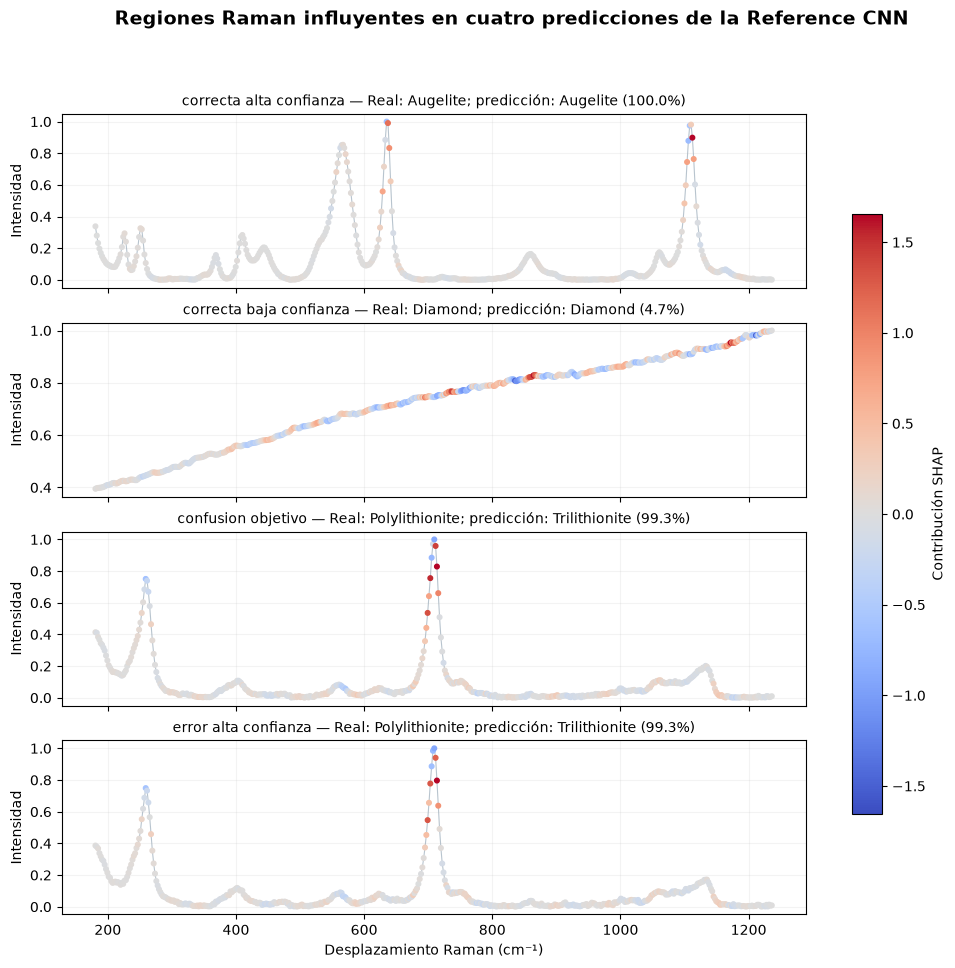

Figura resumen: /Users/nico/anaconda_projects/TFM - FINAL/reference_cnn_shap_results/FIGURA_RESUMEN_SHAP_REFERENCE_CNN.png


In [8]:
def safe_filename(text):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text)).strip("_")

def plot_case(case_number):
    row = cases.iloc[case_number]
    signal = X_cases[case_number, :, 0]
    attribution = predicted_shap[case_number, :, 0]
    limit = max(float(np.max(np.abs(attribution))), 1e-12)

    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, constrained_layout=True)
    axes[0].plot(raman_grid, signal, color="#16324F", linewidth=1.2)
    axes[0].set_ylabel("Intensidad normalizada")
    axes[0].set_title(
        f"{row.case_id} | Real: {row.true_label} | Predicción: {row.predicted_label} "
        f"| Probabilidad: {row.confidence:.3f}"
    )
    axes[0].grid(alpha=0.18)

    axes[1].plot(raman_grid, attribution, color="#555555", linewidth=0.7)
    axes[1].fill_between(raman_grid, 0, attribution, where=attribution >= 0,
                         color="#D95F59", alpha=0.8, label="Favorece la predicción")
    axes[1].fill_between(raman_grid, 0, attribution, where=attribution < 0,
                         color="#3A7CA5", alpha=0.8, label="Reduce la predicción")
    axes[1].axhline(0, color="black", linewidth=0.7)
    axes[1].set_ylim(-1.05 * limit, 1.05 * limit)
    axes[1].set_xlabel("Desplazamiento Raman (cm⁻¹)")
    axes[1].set_ylabel("Contribución SHAP")
    axes[1].legend(loc="upper right", fontsize=8)
    axes[1].grid(alpha=0.18)

    path = CASE_FIGURE_DIR / f"{row.case_id}_{safe_filename(row.true_label)}_vs_{safe_filename(row.predicted_label)}.png"
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.close(fig)
    return path

case_paths = [plot_case(i) for i in range(len(cases))]
print(f"✓ {len(case_paths)} figuras guardadas en {CASE_FIGURE_DIR}")

# Una observación por grupo para la figura compacta de la memoria.
summary_positions = []
for group_name in cases["case_group"].drop_duplicates():
    summary_positions.append(int(cases.index[cases["case_group"].eq(group_name)][0]))
summary_positions = summary_positions[:4]

fig, axes = plt.subplots(len(summary_positions), 1, figsize=(12, 2.6 * len(summary_positions)), sharex=True)
axes = np.atleast_1d(axes)
last_scatter = None
for axis, case_number in zip(axes, summary_positions):
    row = cases.iloc[case_number]
    signal = X_cases[case_number, :, 0]
    attribution = predicted_shap[case_number, :, 0]
    limit = max(float(np.max(np.abs(attribution))), 1e-12)
    axis.plot(raman_grid, signal, color="#B8C4CE", linewidth=0.8, zorder=1)
    last_scatter = axis.scatter(
        raman_grid, signal, c=attribution, cmap="coolwarm",
        norm=TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit), s=11, zorder=2,
    )
    axis.set_ylabel("Intensidad")
    axis.set_title(
        f"{row.case_group.replace('_', ' ')} — Real: {row.true_label}; "
        f"predicción: {row.predicted_label} ({row.confidence:.1%})",
        fontsize=10,
    )
    axis.grid(alpha=0.15)
axes[-1].set_xlabel("Desplazamiento Raman (cm⁻¹)")
if last_scatter is not None:
    fig.colorbar(last_scatter, ax=axes, shrink=0.75, label="Contribución SHAP")
fig.suptitle("Regiones Raman influyentes en cuatro predicciones de la Reference CNN", fontsize=14, weight="bold")
summary_path = OUTPUT_DIR / "FIGURA_RESUMEN_SHAP_REFERENCE_CNN.png"
fig.savefig(summary_path, dpi=300, bbox_inches="tight")
plt.show()
print("Figura resumen:", summary_path.resolve())

## 9. Regiones Raman más influyentes

Para evitar una interpretación excesiva de puntos adyacentes y correlacionados, se agrupan las contribuciones en ventanas no solapadas. La importancia absoluta permite ordenar regiones; la contribución firmada indica si cada región favorece o reduce la clase predicha.

,case_id,case_group,true_label,predicted_label,confidence,window_start_index,window_stop_index,raman_start_cm-1,raman_end_cm-1,signed_contribution,absolute_importance
0,C01,correcta_alta_confianza,Augelite,Augelite,1.000,448,456,1106.03,1120.49,1.77752,5.17844
1,C01,correcta_alta_confianza,Augelite,Augelite,1.000,216,224,626.85,641.30,3.27767,5.06644
2,C01,correcta_alta_confianza,Augelite,Augelite,1.000,440,448,1089.51,1103.97,2.14537,2.17184
3,C01,correcta_alta_confianza,Augelite,Augelite,1.000,472,480,1155.60,1170.06,-0.92212,1.02546
4,C01,correcta_alta_confianza,Augelite,Augelite,1.000,480,488,1172.13,1186.58,-0.45193,1.01978
5,C02,correcta_alta_confianza,Augelite,Augelite,1.000,216,224,626.85,641.30,3.34921,5.12020
6,C02,correcta_alta_confianza,Augelite,Augelite,1.000,448,456,1106.03,1120.49,2.02989,4.34645
7,C02,correcta_alta_confianza,Augelite,Augelite,1.000,440,448,1089.51,1103.97,1.91968,1.99068
8,C02,correcta_alta_confianza,Augelite,Augelite,1.000,472,480,1155.60,1170.06,-1.18722,1.40051
9,C02,correcta_alta_confianza,Augelite,Augelite,1.000,488,496,1188.65,1203.11,1.26904,1.26904


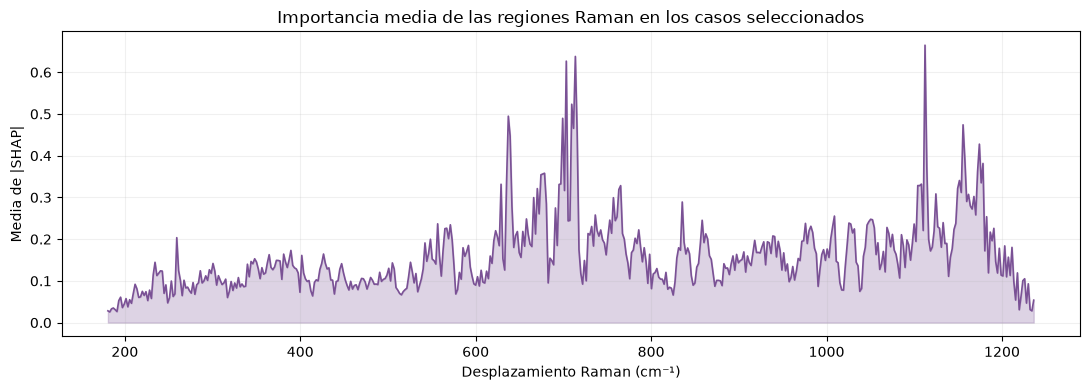

In [9]:
def region_table_for_case(case_number):
    attribution = predicted_shap[case_number, :, 0]
    rows = []
    for start in range(0, len(raman_grid), WINDOW_POINTS):
        stop = min(start + WINDOW_POINTS, len(raman_grid))
        window_values = attribution[start:stop]
        rows.append({
            "window_start_index": start,
            "window_stop_index": stop,
            "raman_start_cm-1": float(raman_grid[start]),
            "raman_end_cm-1": float(raman_grid[stop - 1]),
            "signed_contribution": float(window_values.sum()),
            "absolute_importance": float(np.abs(window_values).sum()),
        })
    table = pd.DataFrame(rows).sort_values("absolute_importance", ascending=False).head(TOP_WINDOWS_PER_CASE)
    case = cases.iloc[case_number]
    table.insert(0, "confidence", float(case.confidence))
    table.insert(0, "predicted_label", case.predicted_label)
    table.insert(0, "true_label", case.true_label)
    table.insert(0, "case_group", case.case_group)
    table.insert(0, "case_id", case.case_id)
    return table

region_tables = [region_table_for_case(i) for i in range(len(cases))]
important_regions = pd.concat(region_tables, ignore_index=True)
important_regions.to_csv(OUTPUT_DIR / "TOP_RAMAN_REGIONS_BY_CASE.csv", index=False)
display(important_regions.head(20).style.format({
    "confidence": "{:.3f}",
    "raman_start_cm-1": "{:.2f}",
    "raman_end_cm-1": "{:.2f}",
    "signed_contribution": "{:.5f}",
    "absolute_importance": "{:.5f}",
}))

global_importance = np.mean(np.abs(predicted_shap[:, :, 0]), axis=0)
global_table = pd.DataFrame({
    "raman_shift_cm-1": raman_grid,
    "mean_absolute_shap": global_importance,
})
global_table.to_csv(OUTPUT_DIR / "MEAN_ABSOLUTE_SHAP_SELECTED_CASES.csv", index=False)

plt.figure(figsize=(11, 4))
plt.plot(raman_grid, global_importance, color="#7A5195", linewidth=1.2)
plt.fill_between(raman_grid, 0, global_importance, color="#7A5195", alpha=0.25)
plt.xlabel("Desplazamiento Raman (cm⁻¹)")
plt.ylabel("Media de |SHAP|")
plt.title("Importancia media de las regiones Raman en los casos seleccionados")
plt.grid(alpha=0.18)
plt.tight_layout()
global_path = OUTPUT_DIR / "IMPORTANCIA_GLOBAL_SHAP_CASOS_SELECCIONADOS.png"
plt.savefig(global_path, dpi=250, bbox_inches="tight")
plt.show()

## 10. Comprobación mediante oclusión

Se sustituyen las regiones con mayor importancia SHAP por el espectro medio del fondo y se compara la caída de probabilidad con la producida al ocultar el mismo número de regiones elegidas al azar. Una caída mayor al ocultar regiones SHAP aporta evidencia de fidelidad local, aunque no constituye una prueba causal.

,case_id,true_label,predicted_label,original_probability,probability_after_shap_occlusion,probability_after_random_occlusion,drop_shap_regions,drop_random_regions
0,C01,Augelite,Augelite,0.9999,0.9640,0.9996,0.0360,0.0003
1,C02,Augelite,Augelite,0.9999,0.9548,0.9995,0.0451,0.0004
2,C03,Augelite,Augelite,0.9999,0.5647,0.9997,0.4352,0.0001
3,C04,Augelite,Augelite,0.9999,0.4637,0.9994,0.5361,0.0004
4,C05,Diamond,Diamond,0.0473,0.0204,0.0100,0.0269,0.0373
5,C06,Siegenite,Siegenite,0.0491,0.0572,0.0194,-0.0081,0.0297
6,C07,Magnesio-fluoro-hastingsite,Magnesio-fluoro-hastingsite,0.0495,0.2199,0.0511,-0.1704,-0.0016
7,C08,Talc,Talc,0.0541,0.0015,0.0166,0.0527,0.0375
8,C09,Polylithionite,Trilithionite,0.9932,0.4854,0.9686,0.5078,0.0246
9,C10,Actinolite,Pargasite,0.8760,0.0106,0.6662,0.8655,0.2098


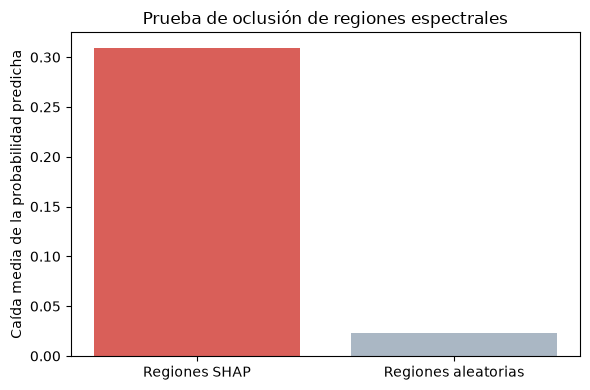

In [10]:
background_mean = X_background.mean(axis=0)
rng = np.random.default_rng(SEED)
n_windows = int(np.ceil(len(raman_grid) / WINDOW_POINTS))

def renormalize(signal):
    result = signal.copy()
    scale = float(np.max(np.abs(result)))
    return result / scale if scale > 1e-12 else result

def occlude_windows(signal, window_numbers):
    changed = signal.copy()
    for window_number in window_numbers:
        start = int(window_number * WINDOW_POINTS)
        stop = min(start + WINDOW_POINTS, len(raman_grid))
        changed[start:stop, :] = background_mean[start:stop, :]
    return renormalize(changed)

occlusion_rows = []
for case_number, row in cases.iterrows():
    attribution = predicted_shap[case_number, :, 0]
    window_scores = np.array([
        np.abs(attribution[start:min(start + WINDOW_POINTS, len(attribution))]).sum()
        for start in range(0, len(attribution), WINDOW_POINTS)
    ])
    shap_windows = np.argsort(window_scores)[::-1][:OCCLUSION_WINDOWS]
    available_random = np.setdiff1d(np.arange(n_windows), shap_windows)
    random_windows = rng.choice(available_random, size=OCCLUSION_WINDOWS, replace=False)

    original = X_cases[case_number]
    shap_occluded = occlude_windows(original, shap_windows)
    random_occluded = occlude_windows(original, random_windows)
    class_index = int(row.predicted_index)
    modified = np.stack([shap_occluded, random_occluded])
    modified_probability = model.predict(modified, verbose=0)[:, class_index]
    original_probability = float(row.confidence)

    occlusion_rows.append({
        "case_id": row.case_id,
        "true_label": row.true_label,
        "predicted_label": row.predicted_label,
        "original_probability": original_probability,
        "probability_after_shap_occlusion": float(modified_probability[0]),
        "probability_after_random_occlusion": float(modified_probability[1]),
        "drop_shap_regions": original_probability - float(modified_probability[0]),
        "drop_random_regions": original_probability - float(modified_probability[1]),
    })

occlusion_results = pd.DataFrame(occlusion_rows)
occlusion_results.to_csv(OUTPUT_DIR / "SHAP_OCCLUSION_FIDELITY.csv", index=False)
display(occlusion_results.style.format({c: "{:.4f}" for c in occlusion_results.columns if "probability" in c or "drop" in c}))

summary = occlusion_results[["drop_shap_regions", "drop_random_regions"]].mean()
plt.figure(figsize=(6, 4))
plt.bar(["Regiones SHAP", "Regiones aleatorias"], summary.values, color=["#D95F59", "#AAB7C4"])
plt.ylabel("Caída media de la probabilidad predicha")
plt.title("Prueba de oclusión de regiones espectrales")
plt.axhline(0, color="black", linewidth=0.7)
plt.tight_layout()
occlusion_path = OUTPUT_DIR / "OCLUSION_SHAP_VS_ALEATORIA.png"
plt.savefig(occlusion_path, dpi=250, bbox_inches="tight")
plt.show()

## 11. Estabilidad frente al conjunto de referencia

De manera opcional se repite SHAP con otra observación de entrenamiento por clase. Se calcula la correlación de Spearman entre ambas explicaciones para cuatro casos. Valores altos indican que la distribución de importancia es relativamente estable ante este cambio de referencia.

,case_id,true_label,predicted_label,spearman_rho,p_value
0,C01,Augelite,Augelite,0.938927,1.969718e-238
1,C02,Augelite,Augelite,0.962195,3.075053e-290
2,C03,Augelite,Augelite,0.745934,4.498740e-92
3,C04,Augelite,Augelite,0.884799,2.914155e-171


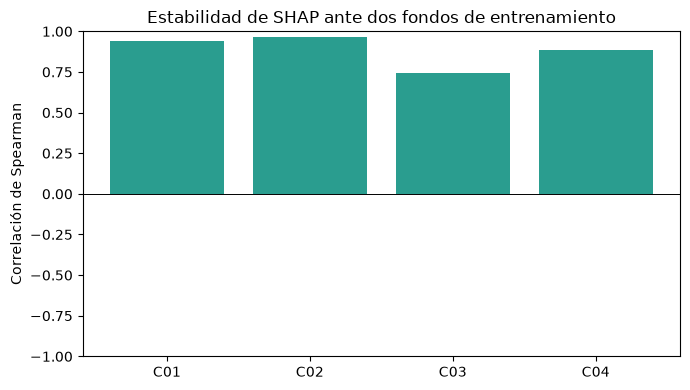

In [11]:
if RUN_BACKGROUND_STABILITY:
    background_meta_2 = class_balanced_background_rows(split_manifest, SEED + 1)
    X_background_2 = load_rows(background_meta_2, "Segundo fondo SHAP")
    explainer_2 = shap.GradientExplainer(logit_model, X_background_2, batch_size=32)
    n_stability = min(STABILITY_CASES, len(X_cases))
    shap_2, explained_2 = ranked_shap_values(explainer_2, X_cases[:n_stability], SEED + 1)
    if not np.array_equal(explained_2, predicted[selected_positions[:n_stability]]):
        raise AssertionError("La clase explicada cambió inesperadamente en la prueba de estabilidad.")

    stability_rows = []
    for i in range(n_stability):
        rho, p_value = spearmanr(
            predicted_shap[i, :, 0],
            shap_2[i, :, 0],
        )
        stability_rows.append({
            "case_id": cases.iloc[i].case_id,
            "true_label": cases.iloc[i].true_label,
            "predicted_label": cases.iloc[i].predicted_label,
            "spearman_rho": float(rho),
            "p_value": float(p_value),
        })
    background_stability = pd.DataFrame(stability_rows)
    background_stability.to_csv(OUTPUT_DIR / "SHAP_BACKGROUND_STABILITY.csv", index=False)
    display(background_stability)

    plt.figure(figsize=(7, 4))
    plt.bar(background_stability["case_id"], background_stability["spearman_rho"], color="#2A9D8F")
    plt.ylim(-1, 1)
    plt.axhline(0, color="black", linewidth=0.7)
    plt.ylabel("Correlación de Spearman")
    plt.title("Estabilidad de SHAP ante dos fondos de entrenamiento")
    plt.tight_layout()
    stability_path = OUTPUT_DIR / "ESTABILIDAD_FONDO_SHAP.png"
    plt.savefig(stability_path, dpi=250, bbox_inches="tight")
    plt.show()
else:
    print("Prueba de estabilidad omitida. Activa RUN_BACKGROUND_STABILITY para ejecutarla.")

## 12. Archivos generados e interpretación

La figura principal recomendada para la memoria es `FIGURA_RESUMEN_SHAP_REFERENCE_CNN.png`. La tabla `TOP_RAMAN_REGIONS_BY_CASE.csv` resume las cinco regiones más influyentes de cada caso. La prueba de oclusión y la estabilidad del fondo deben presentarse como comprobaciones metodológicas, no como validación química.

Una interpretación rigurosa debe indicar que:

1. SHAP explica el comportamiento del modelo respecto al fondo elegido.
2. Las regiones influyentes pueden compararse con picos Raman conocidos, pero la coincidencia requiere revisión de un especialista.
3. Las atribuciones no corrigen el sesgo por clases minoritarias ni convierten la probabilidad *softmax* en certeza.

In [12]:
generated = sorted(path for path in OUTPUT_DIR.rglob("*") if path.is_file())
print("Archivos generados:")
for path in generated:
    print(" -", path.resolve())

print("\nResumen:")
print(f"Casos explicados: {len(cases)}")
print(f"Clases representadas en el fondo: {background_meta['class_index'].nunique()}")
print(f"Media de caída al ocultar regiones SHAP: {occlusion_results['drop_shap_regions'].mean():.4f}")
print(f"Media de caída al ocultar regiones aleatorias: {occlusion_results['drop_random_regions'].mean():.4f}")

Archivos generados:
 - /Users/nico/anaconda_projects/TFM - FINAL/reference_cnn_shap_results/ESTABILIDAD_FONDO_SHAP.png
 - /Users/nico/anaconda_projects/TFM - FINAL/reference_cnn_shap_results/FIGURA_RESUMEN_SHAP_REFERENCE_CNN.png
 - /Users/nico/anaconda_projects/TFM - FINAL/reference_cnn_shap_results/IMPORTANCIA_GLOBAL_SHAP_CASOS_SELECCIONADOS.png
 - /Users/nico/anaconda_projects/TFM - FINAL/reference_cnn_shap_results/MEAN_ABSOLUTE_SHAP_SELECTED_CASES.csv
 - /Users/nico/anaconda_projects/TFM - FINAL/reference_cnn_shap_results/OCLUSION_SHAP_VS_ALEATORIA.png
 - /Users/nico/anaconda_projects/TFM - FINAL/reference_cnn_shap_results/SHAP_BACKGROUND_STABILITY.csv
 - /Users/nico/anaconda_projects/TFM - FINAL/reference_cnn_shap_results/SHAP_OCCLUSION_FIDELITY.csv
 - /Users/nico/anaconda_projects/TFM - FINAL/reference_cnn_shap_results/TOP_RAMAN_REGIONS_BY_CASE.csv
 - /Users/nico/anaconda_projects/TFM - FINAL/reference_cnn_shap_results/case_figures/C01_Augelite_vs_Augelite.png
 - /Users/nico/anaco